<a href="https://colab.research.google.com/github/mdkamrulhasan/data_mining_kdd/blob/main/notebooks/Exploratory_data_Analysis_automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA): Automobile Dataset

## CIS 635 — Knowledge Discovery and Data Mining

Exploratory Data Analysis (EDA) is the process of **understanding a dataset before building models**. In this notebook, we will use an automobile dataset to practice a repeatable EDA workflow:

1. **Understand the dataset** — rows, columns, feature names, and data types.
2. **Assess data quality** — missing values, duplicate records, and suspicious values.
3. **Summarize variables** — descriptive statistics and frequency counts.
4. **Explore distributions** — histograms, box plots, and other univariate views.
5. **Explore relationships** — grouped summaries, scatter plots, and correlation.
6. **Form hypotheses** — use visual and numerical evidence to ask better questions.
7. **Communicate findings** — describe what the data suggests, while distinguishing association from causation.

### A useful EDA mindset

> **Ask a question → inspect the data → visualize/summarize → interpret → ask a better question.**

EDA is **not** simply producing many plots. Each table or visualization should help answer a specific question about the data.

### Learning goals

By the end of this notebook, you should be able to:

- identify the structure and data types of a tabular dataset;
- detect and reason about missing and duplicate data;
- distinguish numeric and categorical variables;
- use descriptive statistics and frequency tables appropriately;
- identify potential outliers and explain why they require investigation;
- examine relationships between variables using grouped summaries, plots, and correlation;
- explain why correlation does **not** establish causation;
- perform a small, reproducible EDA independently on another dataset.

**Dataset:** automobile records used throughout the original notebook. The examples below retain the original workflow and add additional EDA concepts and practice exercises.


## EDA Workflow Used in This Notebook

The sections below follow a practical workflow that you can reuse for other datasets:

| Stage | Key questions |
|---|---|
| 1. Structure | How many observations and features are present? |
| 2. Data types | Which variables are numeric, categorical, or potentially mis-typed? |
| 3. Data quality | Are there missing values, duplicates, impossible values, or suspicious observations? |
| 4. Univariate analysis | What does each important variable look like by itself? |
| 5. Bivariate analysis | How does one variable vary with another? |
| 6. Multivariate analysis | Do several variables together reveal a pattern? |
| 7. Interpretation | What findings are supported by the evidence, and what remains uncertain? |

**Important:** Cleaning decisions should be justified. Removing rows, filling missing values, dropping columns, or treating an observation as an outlier can change the conclusions you draw from the data.


## This notebook covers:



### 1.   Loading Data from **Github**
### 2.   Data Processing through: **Pandas** and **Numpy**
### 3. Data visualizations: **matplotlib** and **seaborn**

[Partly adapted from ](https://colab.research.google.com/github/Tanu-N-Prabhu/Python/blob/master/Exploratory_data_Analysis.ipynb)


# After completing this notebook, you should be able to answer the following (and/or other similar) quesions:

- ## How many rows and columns (features) are there in a table?
- ##  What are the different data types?
- ##  Are there any missing values in any columns? How will you deal with these missing values?
- ##  Can you summarize some features and the data as a whole?
- ##  Are all data trustworthy, or are there any outliers in the data?
- ##  Is there any association among features? Can you explain, if you have detected any association?


#### *Note: We will be answering most of the questions above for a specfic dataset on "automobiles". Its your time to explore similar questions for other datasets, and you will get a fair list of dataset [here ](https://github.com/mdkamrulhasan/data_mining_kdd/tree/main/data)*

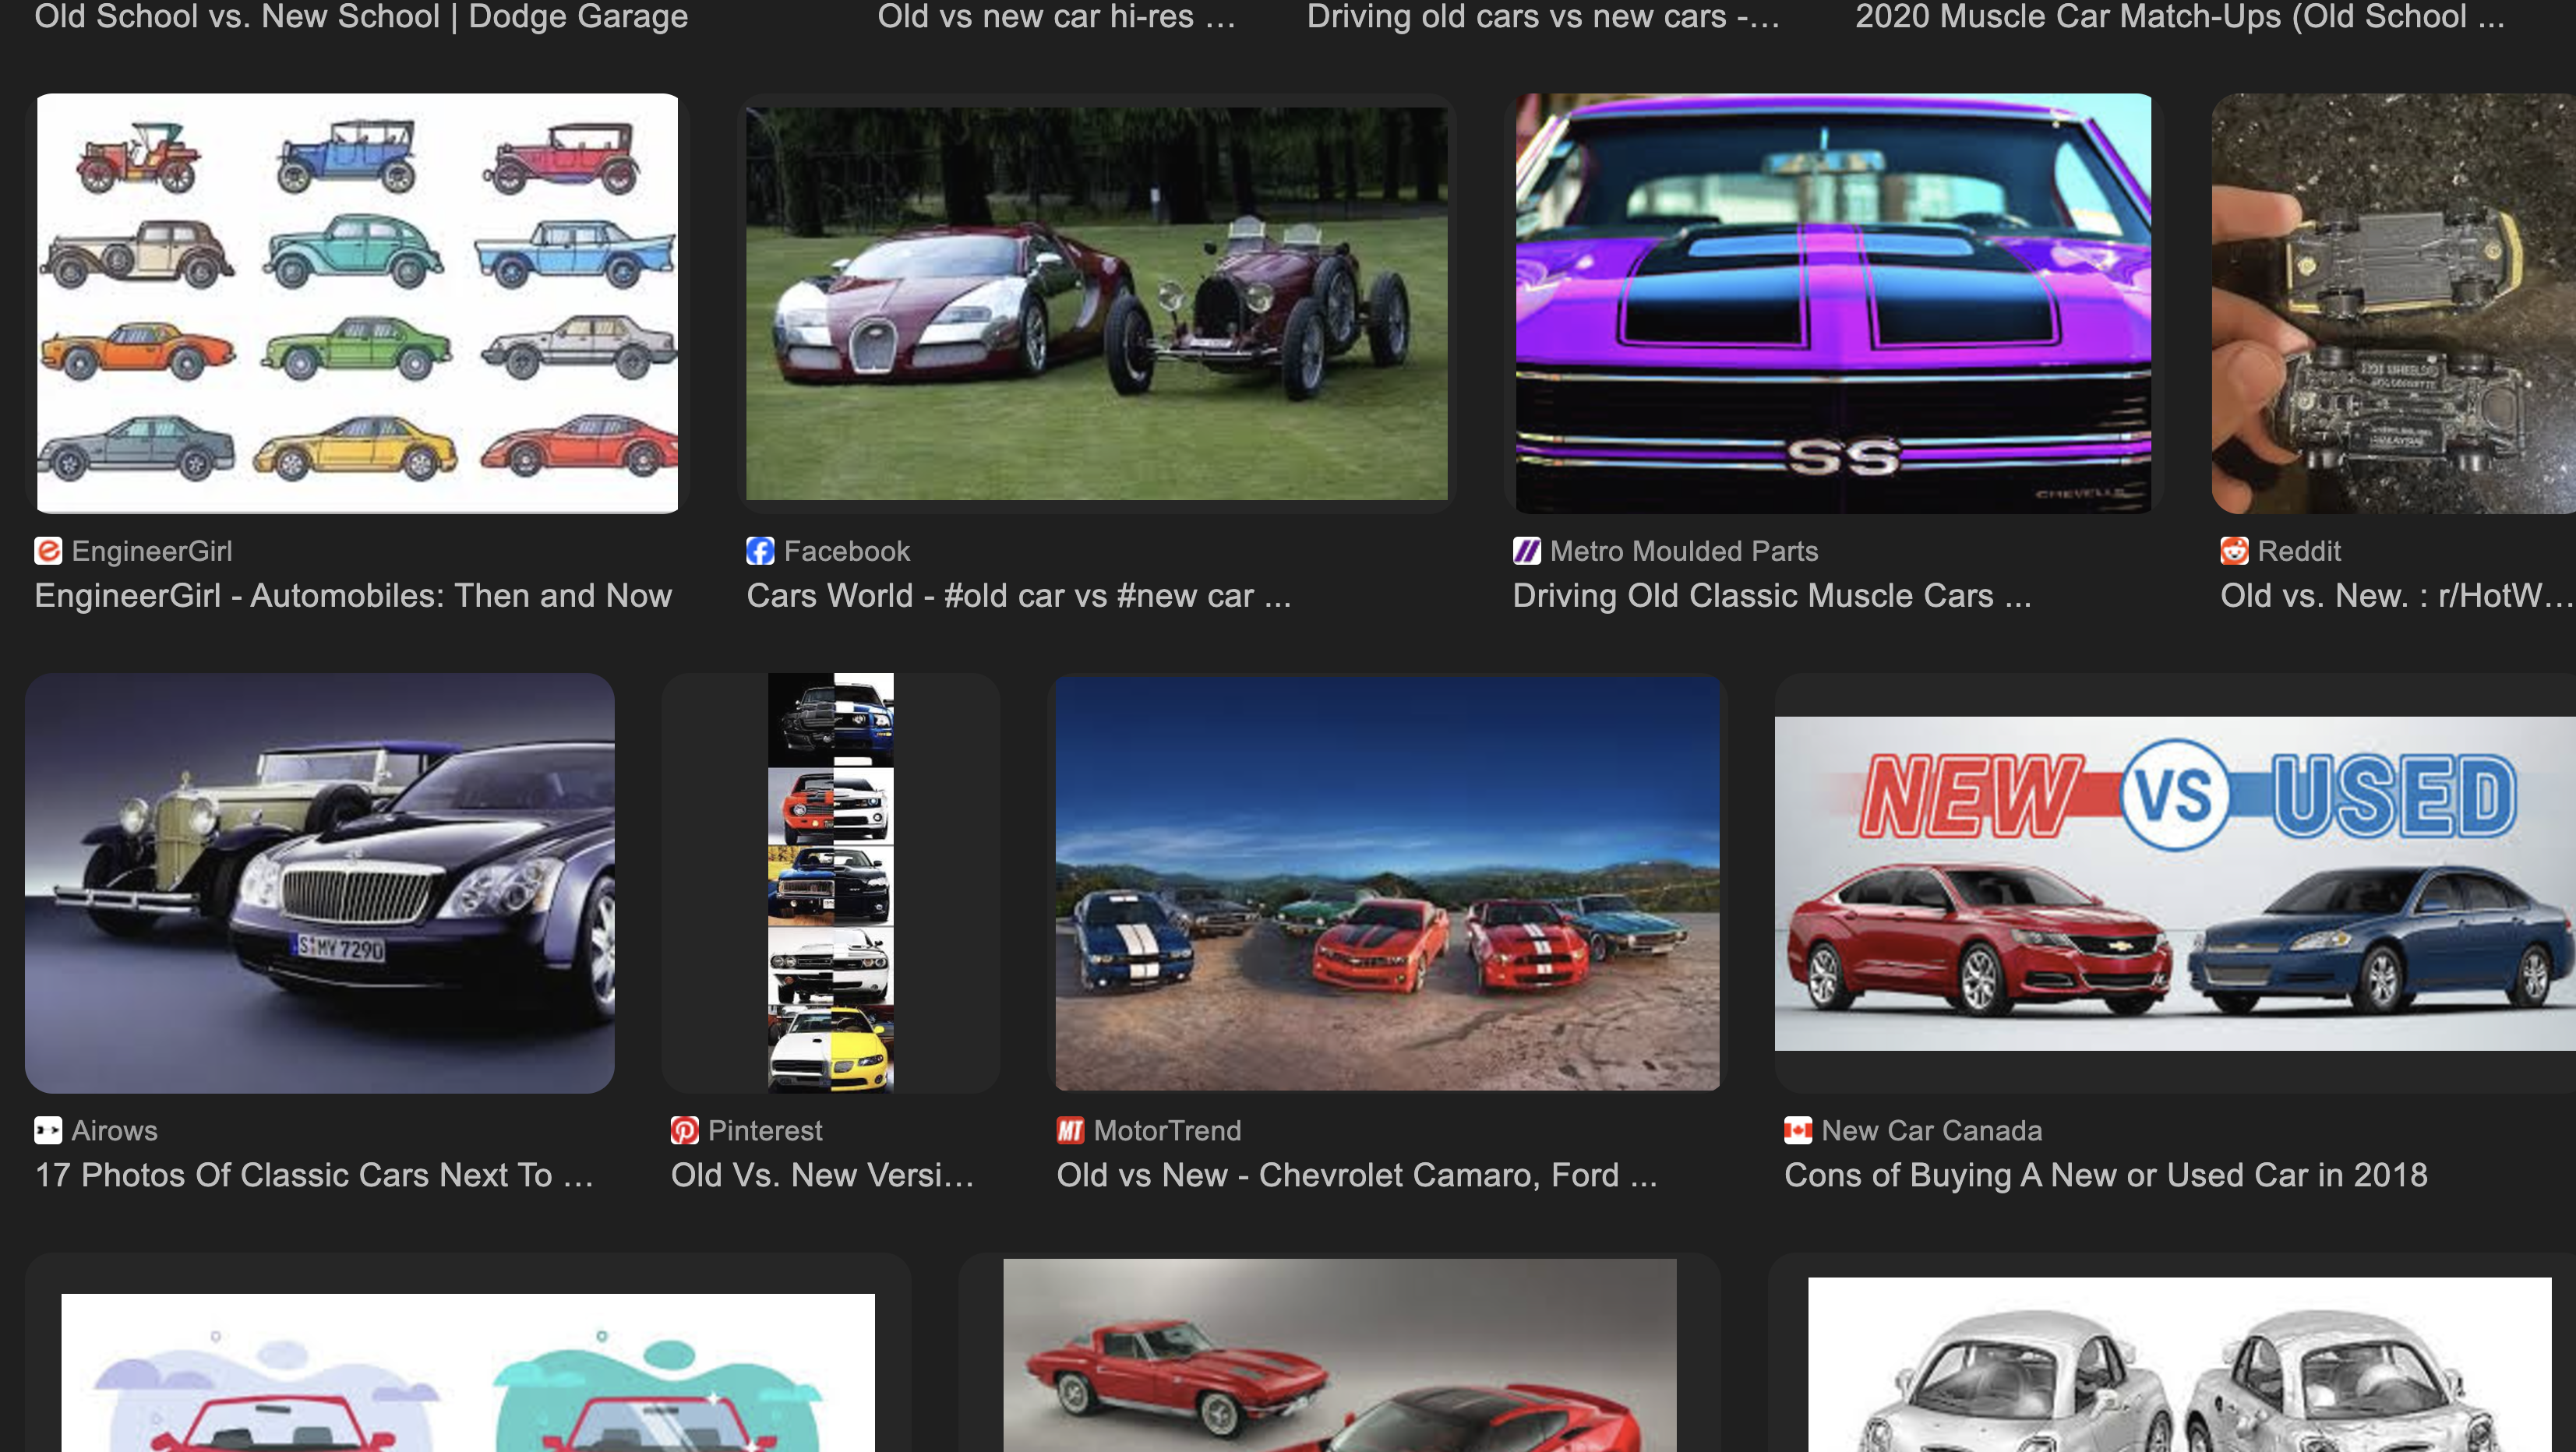

# Importing libraries

### Cell purpose — Import the EDA libraries
We import pandas/NumPy for data manipulation and matplotlib/seaborn for visualization. Run this cell before the analysis cells.

In [ ]:
# data processing
import pandas as pd
import numpy as np
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)



---



## Loading Data from **Github**

### Cell purpose — Load the automobile dataset
Load the CSV into a pandas DataFrame so that the EDA workflow can begin.

In [ ]:
data_url = 'https://raw.githubusercontent.com/mdkamrulhasan/data_mining_kdd/main/data/automobile/automobile.csv'
df = pd.read_csv(data_url)

### Cell purpose — Inspect dataset dimensions
Check the number of observations (rows) and variables (columns).

In [ ]:
df.shape

(11914, 16)

### Cell purpose — Preview observations
Inspect the first few records to understand how the data is organized and what individual observations look like.

In [ ]:
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


### Cell purpose — Inspect feature names
Review the column names before deciding which variables need further investigation or cleaning.

In [ ]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

### Cell purpose — Preview observations
Inspect the first few records to understand how the data is organized and what individual observations look like.

In [ ]:
df.head(2).T

,0,1
Make,BMW,BMW
Model,1 Series M,1 Series
Year,2011,2011
Engine Fuel Type,premium unleaded (required),premium unleaded (required)
Engine HP,335.0,300.0
Engine Cylinders,6.0,6.0
Transmission Type,MANUAL,MANUAL
Driven_Wheels,rear wheel drive,rear wheel drive
Number of Doors,2.0,2.0
Market Category,"Factory Tuner,Luxury,High-Performance","Luxury,Performance"


### Cell purpose — Continue the EDA workflow
Run the cell and interpret the output before moving to the next step.

In [ ]:
df.tail(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995




---



# Checking the data types

### Cell purpose — Inspect data types
Determine which columns pandas treats as numeric, categorical, or object/string data.

In [ ]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


# $\color{red}{\text{Careful when you find a column with object data type !!!}}$
Python loads str or mixed data as the $\color{blue}{\text{object}}$ type:

# Exploring unique values & size of your data

### Cell purpose — Explore categorical values
Inspect unique values and the number of distinct categories to understand variable cardinality and possible data-quality issues.

In [ ]:
df.Make.unique()

array(['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler', 'Nissan',
       'Volvo', 'Mazda', 'Mitsubishi', 'Ferrari', 'Alfa Romeo', 'Toyota',
       'McLaren', 'Maybach', 'Pontiac', 'Porsche', 'Saab', 'GMC',
       'Hyundai', 'Plymouth', 'Honda', 'Oldsmobile', 'Suzuki', 'Ford',
       'Cadillac', 'Kia', 'Bentley', 'Chevrolet', 'Dodge', 'Lamborghini',
       'Lincoln', 'Subaru', 'Volkswagen', 'Spyker', 'Buick', 'Acura',
       'Rolls-Royce', 'Maserati', 'Lexus', 'Aston Martin', 'Land Rover',
       'Lotus', 'Infiniti', 'Scion', 'Genesis', 'HUMMER', 'Tesla',
       'Bugatti'], dtype=object)

### Cell purpose — Explore categorical values
Inspect unique values and the number of distinct categories to understand variable cardinality and possible data-quality issues.

In [ ]:
df['Engine Cylinders'].unique()

array([ 6.,  4.,  5.,  8., 12.,  0., nan, 10.,  3., 16.])

### Cell purpose — Explore categorical values
Inspect unique values and the number of distinct categories to understand variable cardinality and possible data-quality issues.

In [ ]:
df.Make.nunique()

48



---



# Describing some statistics
$\color{blue}{\text{Numeric data columns only}}$

### Cell purpose — Generate descriptive statistics
Use summary statistics to get an initial sense of the center, spread, and range of numeric variables.

In [ ]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


# Making the dataframe light-weight by removing some columns

### Cell purpose — Preview observations
Inspect the first few records to understand how the data is organized and what individual observations look like.

In [ ]:
df = df.drop(columns=['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)
df.head(5)

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


### Cell purpose — Inspect dataset dimensions
Check the number of observations (rows) and variables (columns).

In [ ]:
df.shape

(11914, 10)



---



## Renaming columns

### Cell purpose — Preview observations
Inspect the first few records to understand how the data is organized and what individual observations look like.

In [ ]:
df = df.rename(columns={"Engine HP": "HP", "Engine Cylinders": "Cylinders", "Transmission Type": "Transmission", "Driven_Wheels": "Drive Mode","highway MPG": "MPG-H", "city mpg": "MPG-C", "MSRP": "Price" })
df.head(5)

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500




---



## Dealing with duplicate rows

### Cell purpose — Inspect dataset dimensions
Check the number of observations (rows) and variables (columns).

In [ ]:
df.shape

(11914, 10)

### Cell purpose — Investigate duplicate observations
Identify duplicate rows and compare the dataset before and after duplicate removal.

In [ ]:
df[df.duplicated()].head()

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
14,BMW,1 Series,2013,230.0,6.0,MANUAL,rear wheel drive,28,19,31500
18,Audi,100,1992,172.0,6.0,MANUAL,front wheel drive,24,17,2000
20,Audi,100,1992,172.0,6.0,MANUAL,front wheel drive,24,17,2000
24,Audi,100,1993,172.0,6.0,MANUAL,front wheel drive,24,17,2000
25,Audi,100,1993,172.0,6.0,MANUAL,front wheel drive,24,17,2000


### Cell purpose — Investigate duplicate observations
Identify duplicate rows and compare the dataset before and after duplicate removal.

In [ ]:
df[~df.duplicated()].shape, df[df.duplicated()].shape

### Cell purpose — Investigate duplicate observations
Identify duplicate rows and compare the dataset before and after duplicate removal.

In [ ]:
df[df.duplicated()].shape

### Cell purpose — Preview observations
Inspect the first few records to understand how the data is organized and what individual observations look like.

In [ ]:
duplicate_rows_df = df[df.duplicated()]
duplicate_rows_df.head()

So seen above there are 11914 rows and we are removing 989 rows of duplicate data.

### Cell purpose — Inspect dataset dimensions
Check the number of observations (rows) and variables (columns).

In [ ]:
df_no_duplcates = df.drop_duplicates()
df.shape, df_no_duplcates.shape

# Dealing with Missing values



---



### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df.isnull().sum()

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df.isnull().sum().sum()

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
all_value_df = df[~df.isna().any(axis=1)]

### Cell purpose — Inspect dataset dimensions
Check the number of observations (rows) and variables (columns).

In [ ]:
all_value_df.shape, df.shape

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df[df.isna().any(axis=1)].shape

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df[~df.isna().any(axis=1)].shape

(11816, 10)

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df[df.isna().any(axis=1)].head()

### Question: Can you extract the records with both 'HP'	and 'Cylinders' values are null?

## Column Mean and Mode

### Cell purpose — Examine central tendency
Compare mean and mode as possible summaries. The appropriate choice depends on the variable and the analytical goal.

In [ ]:
df.HP.mean()

### Cell purpose — Examine central tendency
Compare mean and mode as possible summaries. The appropriate choice depends on the variable and the analytical goal.

In [ ]:
df.HP.mode()

### Cell purpose — Examine central tendency
Compare mean and mode as possible summaries. The appropriate choice depends on the variable and the analytical goal.

In [ ]:
df.Model.mode()

## Missing/Null value imputations

## Replacing missing/null values with the mode

### Cell purpose — Examine central tendency
Compare mean and mode as possible summaries. The appropriate choice depends on the variable and the analytical goal.

In [ ]:
cylynder_mode = df.Cylinders.mode()
print(cylynder_mode)
df['Cylinders'] = df['Cylinders'].fillna(cylynder_mode[0])

### You can also replace with mean() or other scalars depending upon your situation.

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df.isna().sum()

### Cell purpose — Assess missingness
Quantify missing values and inspect records containing missing data before deciding how to handle them.

In [ ]:
df.isna().sum().sum()

### Removing records with null values

### Cell purpose — Demonstrate complete-case analysis
Create a version containing only rows with no missing values and compare its size with the original data.

In [ ]:
df_dropped_na = df.dropna()
df_dropped_na.shape



---



## Box plot (Some clue on Outliers)

### Cell purpose — Inspect potential outliers
Use a box plot to identify observations that may be unusually high or low relative to the rest of the distribution.

In [ ]:
sns.boxplot(x=df['Price'])

### Cell purpose — Inspect potential outliers
Use a box plot to identify observations that may be unusually high or low relative to the rest of the distribution.

In [ ]:
sns.boxplot(x=df['MPG-H'])

### Cell purpose — Inspect potential outliers
Use a box plot to identify observations that may be unusually high or low relative to the rest of the distribution.

In [ ]:
sns.boxplot(x=df['MPG-C'])

### Cell purpose — Inspect potential outliers
Use a box plot to identify observations that may be unusually high or low relative to the rest of the distribution.

In [ ]:
sns.boxplot(x=df['HP'])



---



# Frequency (couunt) plot

### Cell purpose — Examine category frequencies
Count the most common automobile makes to understand the composition of the dataset.

In [ ]:
df.Make.value_counts().nlargest(10).plot(kind='bar', figsize=(10,5))
plt.title("Number of cars by make")
plt.ylabel('Number of cars')
plt.xlabel('Make');

# Correlation plot (heatmap)

### Cell purpose — Explore linear association
Calculate correlations among selected numeric variables and visualize them as a heatmap. Remember that correlation does not imply causation.

In [ ]:
plt.figure(figsize=(10,5))
c = df[['HP', 'Cylinders', 'MPG-H', 'MPG-C', 'Price']].corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

## Correlation related questions:

* ### Can you think of some real world example of veraible that are positively correlated ?
* ###  Can you think of some real world example of veraible that are negatively correlated ?





### Cell purpose — Continue the EDA workflow
Run the cell and interpret the output before moving to the next step.

In [ ]:
c

# Scatterplot

### Cell purpose — Examine a numeric relationship
Use a scatter plot to visually investigate how price varies with horsepower.

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['HP'], df['Price'])
ax.set_xlabel('HP')
ax.set_ylabel('Price')
plt.show()

### Cell purpose — Continue the EDA workflow
Run the cell and interpret the output before moving to the next step.

# Questions (Home work)

* ## Average "Chevrolet" price of those vehicles sold after 2000?
* ## Which "Brand" has the maximum number of "models" in the data?
* ## If I mostly drive in the city, what vehicle do you think will be cost effective?
* ## Did you find any outlier in the data? What is your resoning behind this conclusion?
* ## How outliers affect some estimates, say, mean/variance of certain variables? What would you do if you are certain about some outliers in your data?

---
# Additional EDA Practice

The original notebook introduces the core ideas. The following sections extend the analysis so that you can practice a more complete EDA workflow.

## 1. Create an analysis copy

A useful habit is to preserve the original DataFrame and perform cleaning on a separate working copy. This makes it easier to compare before/after results and revisit an earlier decision.


In [ ]:
# Preserve the original data and create a working copy for additional analysis.
df_raw = df.copy()
df_eda = df.copy()

print("Original shape:", df_raw.shape)
print("Working shape:", df_eda.shape)


## 2. Separate numeric and categorical variables

Different variable types require different summaries and visualizations.

- **Numeric variables:** mean, median, standard deviation, quantiles, histograms, box plots, scatter plots.
- **Categorical variables:** frequency counts, proportions, bar charts, grouped summaries.

The distinction is important because applying a numeric statistic to a categorical variable usually does not make sense.


In [ ]:
# Identify numeric and categorical columns in the working DataFrame.
numeric_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_eda.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical/object columns:")
print(categorical_cols)


## 3. Inspect missing values as percentages

A count tells us how many values are missing; a percentage tells us how substantial the missingness is relative to the dataset size.


In [ ]:
# Calculate both the number and percentage of missing values in each column.
missing_summary = pd.DataFrame({
    "missing_count": df_eda.isna().sum(),
    "missing_percent": 100 * df_eda.isna().mean()
})

missing_summary = missing_summary.sort_values("missing_percent", ascending=False)
missing_summary


## 4. Explore distributions with histograms

A histogram helps answer questions such as:

- Is the distribution symmetric or skewed?
- Are there multiple peaks?
- Is most of the data concentrated in a narrow range?
- Are there extreme observations?

Try changing the number of bins and observe how the visual interpretation changes.


In [ ]:
# Plot the distributions of several important numeric variables.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_eda["Price"].plot(kind="hist", bins=40, ax=axes[0, 0], title="Price")
df_eda["HP"].plot(kind="hist", bins=40, ax=axes[0, 1], title="Horsepower (HP)")
df_eda["MPG-H"].plot(kind="hist", bins=30, ax=axes[1, 0], title="Highway MPG")
df_eda["MPG-C"].plot(kind="hist", bins=30, ax=axes[1, 1], title="City MPG")

plt.tight_layout()
plt.show()


## 5. Compare mean and median

The **mean** can be strongly affected by extreme values, while the **median** is more resistant to them. Comparing the two can provide an early clue about skewness.

This does not mean that one measure is always better than the other; the choice depends on the question and the distribution.


In [ ]:
# Compare mean and median for selected numeric variables.
summary = df_eda[["Price", "HP", "MPG-H", "MPG-C"]].agg(["mean", "median", "std"]).T
summary


## 6. Grouped analysis: summarize price by automobile make

EDA becomes more informative when we ask domain-oriented questions. For example:

> How does the typical price vary across automobile makes?

Use both the number of observations and a summary statistic. A mean based on a very small number of vehicles should be interpreted cautiously.


In [ ]:
# Compare the number of records and average/median price for the most common makes.
make_summary = (
    df_eda.groupby("Make")["Price"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
)

make_summary.head(15)


## 7. Investigate a relationship with a scatter plot

Scatter plots can reveal:

- positive or negative trends;
- clusters;
- nonlinear patterns;
- unusual observations;
- changing variability.

A numerical correlation coefficient can summarize a linear association, but it cannot replace visual inspection.


In [ ]:
# Examine the relationship between horsepower and highway fuel economy.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x="HP", y="MPG-H", alpha=0.5)
plt.title("Horsepower vs. Highway MPG")
plt.xlabel("Horsepower (HP)")
plt.ylabel("Highway MPG")
plt.show()


## 8. Examine relationships by category

A single overall relationship can hide differences among groups. A box plot can help compare the distribution of price across selected drive modes.

Start with the categories that occur most often rather than plotting every possible category.


In [ ]:
# Compare price distributions across drive modes.
top_drive_modes = df_eda["Drive Mode"].value_counts().head(4).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_eda[df_eda["Drive Mode"].isin(top_drive_modes)],
    x="Drive Mode",
    y="Price"
)
plt.title("Price Distribution by Drive Mode")
plt.xlabel("Drive Mode")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.show()


## 9. Quantify potential outliers using the IQR rule

The box plot gives a visual clue about potential outliers. The **interquartile range (IQR)** provides a simple numerical rule:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Observations outside these bounds are often called *potential outliers*. They are **not automatically errors**. An expensive car, for example, may be a legitimate observation.


In [ ]:
# Identify potential outliers in Price using the IQR rule.
q1 = df_eda["Price"].quantile(0.25)
q3 = df_eda["Price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outliers = df_eda[
    (df_eda["Price"] < lower_bound) |
    (df_eda["Price"] > upper_bound)
]

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Potential outliers: {len(price_outliers)}")
print(f"Percentage of records: {100 * len(price_outliers) / len(df_eda):.2f}%")

price_outliers[["Make", "Model", "Year", "Price"]].head(10)


## 10. Look for potentially impossible or suspicious values

EDA should also include **domain checks**, not just statistical checks. Ask whether values are plausible.

For automobiles, examples of questions include:

- Are prices positive?
- Are horsepower values positive?
- Are MPG values within a plausible range?
- Are years reasonable for the dataset?

The thresholds below are intentionally simple examples. In a real project, domain expertise should determine the rules.


In [ ]:
# Perform a few basic plausibility checks.
checks = {
    "nonpositive_price": (df_eda["Price"] <= 0).sum(),
    "nonpositive_hp": (df_eda["HP"] <= 0).sum(),
    "nonpositive_mpg_h": (df_eda["MPG-H"] <= 0).sum(),
    "nonpositive_mpg_c": (df_eda["MPG-C"] <= 0).sum(),
}

pd.Series(checks, name="count")


## 11. Pairwise relationships among selected variables

A correlation matrix provides a compact numerical summary of linear relationships. A pair plot can add visual context.

Use a **small subset** of variables for pair plots; plotting every feature can become difficult to interpret.


In [ ]:
# Visualize pairwise relationships for a small set of numeric variables.
pair_cols = ["HP", "Cylinders", "MPG-H", "MPG-C", "Price"]
sns.pairplot(df_eda[pair_cols].dropna(), corner=True)
plt.show()


## 12. EDA interpretation checkpoint

Before moving to modeling, try to write a short narrative rather than simply listing outputs.

A useful EDA summary should answer:

1. **What is in the dataset?**
2. **What data-quality issues did you find?**
3. **What are the most important distributions or patterns?**
4. **Which variables appear related?**
5. **What findings are surprising or worth investigating further?**
6. **What cleaning decisions did you make, and why?**
7. **What questions remain unanswered?**

Avoid statements such as *“HP causes price to increase”* based only on a scatter plot or correlation. EDA can reveal **association**, but causation requires an appropriate research design and additional evidence.


---
# Student Exercises: Check Your Understanding

Complete the exercises below without copying the earlier cells verbatim. For each exercise, include a short interpretation of your result.

### Exercise 1 — Dataset structure
1. Report the number of observations and features.
2. Identify at least three numeric variables and three categorical/object variables.
3. Which variable would you consider the likely **target/outcome** if the question were to predict automobile price? Explain your reasoning.

### Exercise 2 — Data quality
1. Produce a table showing the missing-value count and percentage for every column.
2. Identify the column with the greatest amount of missing data.
3. Explain one advantage and one disadvantage of removing rows with missing values.

### Exercise 3 — Duplicates
1. Count the duplicate rows.
2. Calculate what percentage of the dataset they represent.
3. Explain why blindly removing duplicates could sometimes be inappropriate.

### Exercise 4 — Distribution
Choose **Price** or **HP**:
1. Create a histogram.
2. Report its mean and median.
3. Based on the histogram and mean/median comparison, describe the shape of the distribution.
4. Identify one possible consequence of a strongly skewed distribution for later analysis.

### Exercise 5 — Grouped analysis
Determine the **five makes with the highest median price**.
- Report the make, number of records, and median price.
- Do not rank a make using median price alone; discuss whether the number of observations affects how confidently you would interpret the result.

### Exercise 6 — Relationship
Investigate the relationship between **MPG-C** and **MPG-H**.
1. Create a scatter plot.
2. Calculate their Pearson correlation.
3. Describe whether the relationship appears positive, negative, or weak.
4. Explain why the correlation coefficient alone is not sufficient evidence that the relationship is perfectly linear.

### Exercise 7 — Outliers
Use the IQR rule to identify potential outliers in **HP**.
1. Calculate Q1, Q3, IQR, and the lower/upper bounds.
2. Report the number and percentage of potential outliers.
3. Inspect at least five potential outliers.
4. Decide whether you have enough evidence to remove them. Explain your decision.

### Exercise 8 — Compare groups
Compare **Price** across at least three categories of **Transmission**.
- Use a suitable visualization.
- Report an appropriate summary statistic.
- Describe one pattern and one limitation of your comparison.

### Exercise 9 — EDA mini-challenge
Choose one question that can be answered using this automobile dataset. Examples:

- Do more powerful vehicles tend to be more expensive?
- Are newer vehicles generally more expensive?
- Is fuel economy associated with horsepower?
- Does price differ across drive modes?

Your submission should include:
1. the question;
2. the variables used;
3. at least one numerical summary;
4. at least one visualization;
5. a short interpretation;
6. one limitation or alternative explanation.

### Exercise 10 — Think like a data scientist
Suppose you find a very expensive vehicle that is flagged as an outlier.

**Question:** Should you automatically delete it?

Write 3–5 sentences explaining what additional evidence you would want before removing the observation.


## Optional Extension — Independent EDA

Repeat the workflow on a different dataset from the course repository.

Your goal is **not** to reproduce every plot in this notebook. Instead, select the EDA steps that are appropriate for your dataset and justify your choices.

A strong EDA notebook should demonstrate:

- a clear analytical question;
- understanding of the data structure;
- data-quality assessment;
- appropriate summaries;
- meaningful visualizations;
- interpretation of patterns;
- explicit discussion of limitations and uncertainty.
